<a target="_blank" href="https://colab.research.google.com/github/TransformerLensOrg/TransformerLens/blob/main/demos/LIT_Integration_Demo.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# TransformerLens + LIT Integration Demo

This notebook demonstrates how to use Google's **Learning Interpretability Tool (LIT)** with **TransformerLens** for interactive model analysis and visualization.

**What you'll learn:**
1. Setting up the LIT integration
2. Visualizing attention patterns
3. Exploring token predictions
4. Using embedding projector
5. Token salience/gradient analysis

**References:**
- [TransformerLens](https://github.com/TransformerLensOrg/TransformerLens)
- [LIT Documentation](https://pair-code.github.io/lit/)
- [LIT Paper](https://arxiv.org/abs/2008.05122)

# Setup
(No need to read - just run these cells)

In [1]:
# Detect environment
import os

DEVELOPMENT_MODE = False

# Detect if we're running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally (VSCode/Jupyter)")

# Install packages if in Colab
if IN_COLAB:
    %pip install -q transformer_lens lit-nlp

# Hot reload in development mode
if not IN_COLAB and DEVELOPMENT_MODE:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None and not ip.extension_manager.loaded:
        ip.extension_manager.load('autoreload')
        %autoreload 2

Running locally (VSCode/Jupyter)


# Imports

In [2]:
# Core imports
import torch
import numpy as np
from transformer_lens import HookedTransformer

# LIT integration imports
from transformer_lens.lit import (
    HookedTransformerLIT,
    HookedTransformerLITConfig,
    SimpleTextDataset,
    PromptCompletionDataset,
    IOIDataset,
    InductionDataset,
    serve,
    check_lit_installed,
)

# Verify LIT is available
if check_lit_installed():
    print("LIT is installed and available")
else:
    print("WARNING: LIT (lit-nlp) is not installed. Please run: pip install lit-nlp")

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

/Users/Hetansh/Github/open-source-contribution/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LIT is installed and available
Using device: cpu


# Load a Model

Let's load GPT-2 Small as our example model. TransformerLens supports 50+ models out of the box.

In [3]:
# Load GPT-2 Small (124M parameters)
# Other options: "gpt2-medium", "gpt2-large", "gpt2-xl", "pythia-70m", etc.
model_name = "gpt2-small"

print(f"Loading {model_name}...")
model = HookedTransformer.from_pretrained(
    model_name,
    device=device,
)
print(f"Loaded model: {model.cfg.model_name}")
print(f"  Layers: {model.cfg.n_layers}")
print(f"  Heads: {model.cfg.n_heads}")
print(f"  d_model: {model.cfg.d_model}")

Loading gpt2-small...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-small into HookedTransformer
Loaded model: gpt2
  Layers: 12
  Heads: 12
  d_model: 768


# Create LIT Wrapper

Now we wrap the HookedTransformer with our LIT wrapper to enable all the visualization features.

In [4]:
# Configure the wrapper
config = HookedTransformerLITConfig(
    max_seq_length=256,         # Maximum input length
    batch_size=4,               # Batch size for inference
    top_k=10,                   # Number of top predictions to show
    compute_gradients=True,     # Enable gradient-based salience
    output_attention=True,      # Output attention patterns
    output_embeddings=True,     # Output embeddings for projector
    output_all_layers=False,    # Just key layers (faster)
    prepend_bos=True,           # Prepend BOS token
)

# Create the wrapper
lit_model = HookedTransformerLIT(model, config=config)

print(f"Created LIT wrapper: {lit_model.description()}")
print(f"\nInput spec keys: {list(lit_model.input_spec().keys())}")
print(f"Output spec keys: {list(lit_model.output_spec().keys())}")

Created LIT wrapper: TransformerLens: gpt2 (12L, 12H, d=768)

Input spec keys: ['text', 'tokens', 'token_embeddings', 'target_mask']
Output spec keys: ['tokens', 'top_k_tokens', 'input_embeddings', 'cls_embedding', 'mean_embedding', 'layer_0/embeddings', 'layer_6/embeddings', 'layer_11/embeddings', 'layer_0/attention', 'layer_1/attention', 'layer_2/attention', 'layer_3/attention', 'layer_4/attention', 'layer_5/attention', 'layer_6/attention', 'layer_7/attention', 'layer_8/attention', 'layer_9/attention', 'layer_10/attention', 'layer_11/attention', 'grad_l2', 'grad_dot_input']


# Create Datasets

LIT needs datasets to visualize. We provide several dataset types for different analysis scenarios.

In [5]:
# Simple text dataset for general exploration
simple_examples = [
    "The capital of France is Paris.",
    "Machine learning is a subset of artificial intelligence.",
    "The quick brown fox jumps over the lazy dog.",
    "To be or not to be, that is the question.",
    "The meaning of life is",
    "In the beginning, there was",
    "The best programming language is",
]

simple_dataset = SimpleTextDataset.from_strings(
    simple_examples,
    name="General Examples"
)
print(f"Created: {simple_dataset.description()}")

Created: General Examples: 7 examples


In [6]:
# Prompt-completion dataset for generation analysis
prompt_completion_pairs = [
    ("The capital of France is", " Paris"),
    ("The capital of Germany is", " Berlin"),
    ("2 + 2 =", " 4"),
    ("Water freezes at", " 0 degrees"),
    ("The sun rises in the", " east"),
]

prompt_dataset = PromptCompletionDataset.from_pairs(
    prompt_completion_pairs,
    name="Factual Completions"
)
print(f"Created: {prompt_dataset.description()}")

Created: Factual Completions: 5 prompt-completion pairs


In [7]:
# IOI (Indirect Object Identification) dataset
# This is commonly used in mechanistic interpretability research
ioi_dataset = IOIDataset.generate(
    n_examples=50,
    seed=42,
    name="IOI Task"
)
print(f"Created: {ioi_dataset.description()}")

# Show an example
print(f"\nExample: {ioi_dataset.examples[0]['text']}")
print(f"Expected answer: {ioi_dataset.examples[0]['answer']}")

Created: IOI Task: 50 IOI examples

Example: When Ivy and John went to the store, Ivy gave a phone to
Expected answer: John


In [8]:
# Induction dataset for analyzing induction heads
induction_dataset = InductionDataset.generate_simple(
    n_examples=30,
    seed=42,
    name="Induction Patterns"
)
print(f"Created: {induction_dataset.description()}")

# Show an example
print(f"\nExample: {induction_dataset.examples[0]['text']}")
print(f"Pattern: {induction_dataset.examples[0]['pattern']}")

Created: Induction Patterns: 30 induction examples

Example: The cat sat on the mat Then, later, The
Pattern: The cat sat on the mat


# Test the Wrapper

Before launching LIT, let's verify the wrapper works correctly.

In [9]:
# Test a single prediction
test_input = {"text": "The capital of France is"}

print("Running prediction...")
outputs = list(lit_model.predict([test_input]))
output = outputs[0]

print(f"\nInput: {test_input['text']}")
print(f"\nTokens: {output['tokens']}")
print(f"\nTop predictions for last position:")
for token, prob in output['top_k_tokens'][-1][:5]:
    print(f"  {repr(token):15s} {prob:.4f}")

# Check available outputs
print(f"\nAvailable output fields: {list(output.keys())}")

Running prediction...

Input: The capital of France is

Tokens: ['<|endoftext|>', 'The', '▁capital', '▁of', '▁France', '▁is']

Top predictions for last position:
  ' now'          0.0475
  ' the'          0.0374
  ' a'            0.0355
  ' home'         0.0309
  ' in'           0.0270

Available output fields: ['tokens', 'top_k_tokens', 'input_embeddings', 'cls_embedding', 'mean_embedding', 'layer_0/embeddings', 'layer_6/embeddings', 'layer_11/embeddings', 'layer_0/attention', 'layer_1/attention', 'layer_2/attention', 'layer_3/attention', 'layer_4/attention', 'layer_5/attention', 'layer_6/attention', 'layer_7/attention', 'layer_8/attention', 'layer_9/attention', 'layer_10/attention', 'layer_11/attention', 'grad_l2', 'grad_dot_input']


In [10]:
# Check embedding shapes
if 'cls_embedding' in output:
    print(f"CLS embedding shape: {output['cls_embedding'].shape}")
if 'mean_embedding' in output:
    print(f"Mean embedding shape: {output['mean_embedding'].shape}")
if 'input_embeddings' in output:
    print(f"Input embeddings shape: {output['input_embeddings'].shape}")

CLS embedding shape: (768,)
Mean embedding shape: (768,)
Input embeddings shape: (6, 768)


In [11]:
# Check attention pattern shapes
attention_keys = [k for k in output.keys() if 'attention' in k]
print(f"Attention layers: {len(attention_keys)}")

if attention_keys:
    first_attn = output[attention_keys[0]]
    print(f"Attention shape per layer: {first_attn.shape}")
    print(f"  (heads, query_pos, key_pos)")

Attention layers: 12
Attention shape per layer: (12, 6, 6)
  (heads, query_pos, key_pos)


# Launch LIT Server

Start the LIT server to visualize and analyze the model. This opens an interactive UI in your browser at http://localhost:5433.

**Note:** The server blocks the notebook. Restart the kernel to stop it.

In [12]:
# Suppress LIT's internal warnings about NoneDataset
import logging
logging.getLogger('absl').setLevel(logging.ERROR)

# Launch LIT server - open http://localhost:5433 in your browser
serve(
    models={"gpt2-small": lit_model},
    datasets={
        "general": simple_dataset,
        "factual": prompt_dataset,
        "ioi": ioi_dataset,
        "induction": induction_dataset,
    },
    port=5433,
    page_title="TransformerLens + LIT Demo",
)

INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://localhost:5433
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [26/Jan/2026 15:39:51] "POST /get_info HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [26/Jan/2026 15:39:51] "POST /get_dataset?dataset_name=general HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [26/Jan/2026 15:39:52] "POST /get_interpretations?model=gpt2-small&dataset_name=general&interpreter=pca&do_predict=1 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [26/Jan/2026 15:39:52] "POST /get_preds?model=gpt2-small&dataset_name=general&requested_types=MulticlassPreds,RegressionScore&requested_fields= HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [26/Jan/2026 15:39:52] "POST /get_interpretations?model=gpt2-small&dataset_name=general&interpreter=Grad%20L2%20Norm&do_predict=1 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [26/Jan/2026 15:39:52] "POST /get_interpretations?model

# Manual Analysis (Without LIT UI)

You can also use the wrapper directly for programmatic analysis.

Tokens: ['<|endoftext|>', 'When', '▁Mary', '▁and', '▁John', '▁went', '▁to', '▁the', '▁store', ',', '▁Mary', '▁gave', '▁a', '▁book', '▁to']


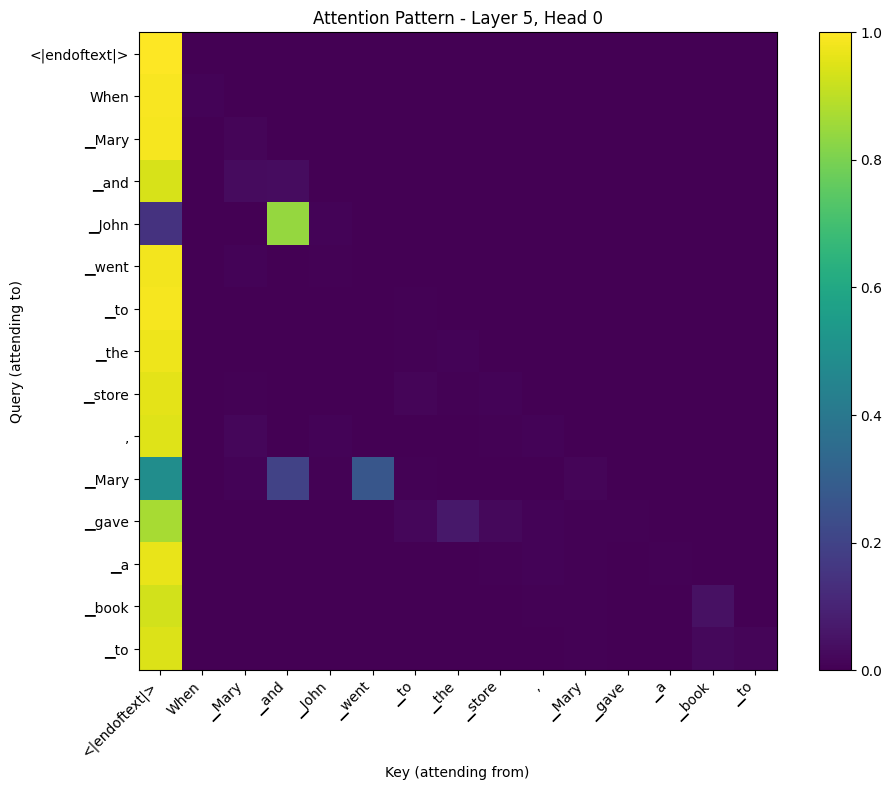

In [13]:
import matplotlib.pyplot as plt

# Analyze attention patterns for a specific example
text = "When Mary and John went to the store, Mary gave a book to"
outputs = list(lit_model.predict([{"text": text}]))[0]

tokens = outputs['tokens']
print(f"Tokens: {tokens}")

# Get attention for layer 5 (if available)
layer = min(5, model.cfg.n_layers - 1)
attn_key = f"layer_{layer}/attention"

if attn_key in outputs:
    attn = outputs[attn_key]  # [heads, q, k]
    
    # Plot attention for head 0
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(attn[0], cmap='viridis')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right')
    ax.set_yticklabels(tokens)
    ax.set_xlabel('Key (attending from)')
    ax.set_ylabel('Query (attending to)')
    ax.set_title(f'Attention Pattern - Layer {layer}, Head 0')
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

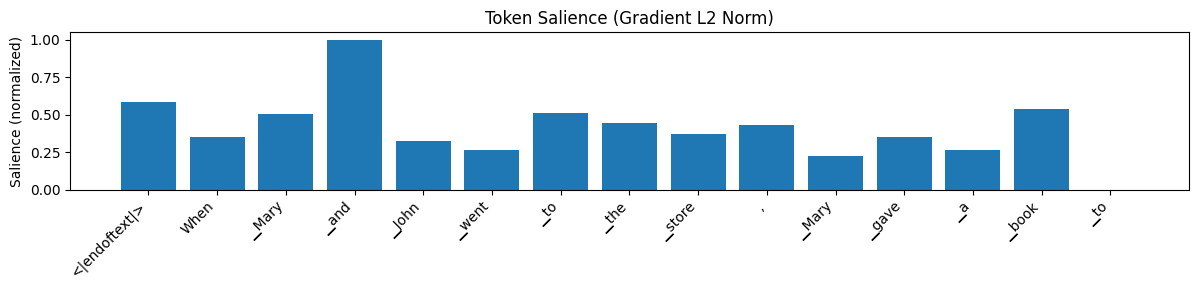

In [14]:
# Visualize token salience (gradient-based)
import numpy as np

if 'grad_l2' in outputs:
    # grad_l2 is now [seq_len, emb_dim] - compute L2 norm per token
    grad_raw = outputs['grad_l2']
    grad_l2 = np.linalg.norm(grad_raw, axis=1)
    
    # Normalize for visualization
    grad_normalized = grad_l2 / grad_l2.max()
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 3))
    bars = ax.bar(range(len(tokens)), grad_normalized)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right')
    ax.set_ylabel('Salience (normalized)')
    ax.set_title('Token Salience (Gradient L2 Norm)')
    plt.tight_layout()
    plt.show()

## Tips for Using LIT with TransformerLens

### Attention Visualization
- Use the **Attention** module to see which tokens the model attends to
- Compare attention patterns across layers to see how information flows
- Look for "induction heads" that copy patterns

### Embedding Projector
- Use UMAP/t-SNE to visualize token embeddings
- Compare embeddings from different layers
- Look for semantic clustering

### Salience Maps
- Gradient-based salience shows which tokens matter most
- Compare `grad_l2` (magnitude) vs `grad_dot_input` (signed)
- Higher values = more important for the prediction

### IOI Task
- A great benchmark for understanding how models do name-binding
- Look for attention to the indirect object name
- Compare behavior with swapped names

### Performance Tips
- Use smaller models (gpt2-small, pythia-70m) for faster iteration
- Disable gradients (`compute_gradients=False`) if you don't need salience
- Reduce `output_all_layers=False` to output fewer embeddings

## References

- **TransformerLens**: https://github.com/TransformerLensOrg/TransformerLens
- **LIT**: https://pair-code.github.io/lit/
- **LIT Paper**: Tenney et al., "The Language Interpretability Tool" (EMNLP 2020)
- **IOI Paper**: Wang et al., "Interpretability in the Wild" (2022)
- **Induction Heads Paper**: Olsson et al., "In-context Learning and Induction Heads" (2022)